# Leg-2 stack bake-off — dense × sparse grid

**Question:** which retrieval stack makes the best standalone labeler? This varies **both** legs, because the baseline is **bge-small + BM25/IDF** — so holding sparse at SPLADE (as an earlier draft did) would confound a dense change with a BM25→SPLADE change. The grid separates them.

**Dense (paid, Qdrant Cloud Inference → OpenRouter):** `qwen3`, `openai3`, `gemini`.
**Sparse (local):** `bm25` (the baseline's own sparse — anchors the dense-only effect), `splade` (current), `opensearch` (neural-sparse doc-v3-gte, via sentence-transformers `SparseEncoder`).

**Primary metric = coverage** (fraction of queries whose judged doc the stack retrieved) — qrels-grounded and **confound-robust**: it's a property of the whole stack, so ranking stacks by it is honest even when both legs vary. Read the coverage grid **down** for the dense effect, **across** for the sparse effect (bm25 → splade → opensearch). Certifiable-decisive and the gate-vs-bge verdict are secondary (biased / a switch-cost check).

> Dense runs are **paid** — and re-paid per cell, not per dense model: `collection()` (`legb.py`) gives every non-`bm25` sparse variant (`minicoil`, `splade`) its own Qdrant collection, and `_vectors_for` (`indexer.py`) skips the local `EmbeddingCache` entirely for any `cloud=True` slot, so each (dense, sparse) cell beyond the shared `bm25` one re-embeds the full corpus through OpenRouter from scratch — up to 3 paid passes per dense model across this grid, not 1. The only reuse is the manual `qwen3 × splade` special-case below, which points at an already-labelled earlier pilot run. **Update:** `LegBPilot._index` now copies dense vectors by point id from the same dense model's existing bm25-paired collection (`reuse_cloud_from`) — a new sparse variant no longer re-pays the dense pass; only ids absent from the source collection fall back to paid embedding. `opensearch` loads a **full transformer locally** (RAM) — run those cells under memguard. Everything is gated behind `RUN_LIVE`.

> **Coverage alone doesn't say a gap is real.** Every stack scores the same 260 queries, so section 4 below runs a paired McNemar test on each comparison the grid invites (sparse effect within a dense model, dense effect within `bm25`) — read that before trusting a coverage delta.

> **A 4th dense candidate, `voyage4` (`voyageai/voyage-4`), was tried and dropped.** Qdrant Cloud Inference's OpenRouter routing for this model 400s with `"VoyageAI embeddings only support text inputs, not multimodal"` even on a plain text `Document` — ruled out `dimensions` in `provider_options` as the cause (same error with it stripped), so the mismatch is inside Qdrant's own request-building for this provider, not anything controllable from `EmbeddingConfig`. Reported upstream; not pursued further here.

In [1]:
import sys
import pathlib

SRC = pathlib.Path.cwd()
SRC = SRC if (SRC / "scripts").exists() else SRC / "src"
sys.path.insert(0, str(SRC))

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from qdrant_client import QdrantClient

from composition.pool_v3 import SCORES, TOL, LabelledPool
from scripts.differentiator_gate import differentiator_gate
from scripts.legb import (
    LEGB_DIR,
    SPARSE_CFG,
    LegBPilot,
    gemini_dense_cfg,
    minicoil_sparse_cfg,
    openai3_dense_cfg,
    opensearch_distill_sparse_cfg,
    opensearch_sparse_cfg,
    qwen_dense_cfg,
    splade_sparse_cfg,
)

load_dotenv()
client = QdrantClient(url=os.environ["QDRANT_CLOUD_URL"], api_key=os.environ["QDRANT_CLOUD_API_KEY"],
                      timeout=120, cloud_inference=True)
pd.set_option("display.width", 170)

LANE = "crumb-legal-qa"
DENSE = {"qwen3": qwen_dense_cfg, "openai3": openai3_dense_cfg, "gemini": gemini_dense_cfg}
# minicoil = contextual IDF-scaled sparse (no expansion); slots between bm25 and splade so
# `bm25 -> minicoil` isolates contextual weighting and `minicoil -> splade` isolates expansion.
SPARSE = {"bm25": lambda: SPARSE_CFG, "minicoil": minicoil_sparse_cfg,
          "splade": splade_sparse_cfg,
          # "opensearch": opensearch_sparse_cfg,  # gte variant (~2h local) — benched this round
          # doc-only family: doc-side expansion, inference-free query (tokenizer+IDF) —
          # the small representative (67M distill vs gte's ~137M+custom code)
          "os_distill": opensearch_distill_sparse_cfg}
print("grid:", list(DENSE), "x", list(SPARSE), "=", len(DENSE) * len(SPARSE), "stacks")

/Users/andrei/projects/hybrid-search-rrf-dataset/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


grid: ['qwen3', 'openai3', 'gemini'] x ['bm25', 'minicoil', 'splade', 'os_distill'] = 12 stacks


## 1. The stacks + draw (dry — no cost)

Each `(dense, sparse)` cell is one stack with its own output dir; `qwen3 × splade` reuses the existing pilot labels (no re-spend). Same stratified draw as the leg-2 pilot, so every cell is scored on the same query set. `plan()` is read-only.

In [2]:
DRAWS = {"all_tied": ("all_tied", 60), "all_zero": ("all_zero", 100), "routes_differ": ("routes_differ", 100)}

def out_dir(dense, sparse):
    return LEGB_DIR / "qwen3_splade" if (dense, sparse) == ("qwen3", "splade") else LEGB_DIR / f"bakeoff_{dense}_{sparse}"

def pilots_for(dense, sparse):
    return [LegBPilot(client, DENSE[dense](), sparse_cfg=SPARSE[sparse](),
                      out_dir=out_dir(dense, sparse), sample=draw, lanes=(LANE,))
            for draw in DRAWS.values()]

# INCLUDE_HEAVY_SPARSE=False skips local-transformer sparse (opensearch, os_distill) for a FAST round —
# it is a real transformer forward pass per doc (~0.7s/doc on CPU, ~2h for a 10k-doc lane);
# bm25/splade are seconds. Set True to add the heavy columns back.
INCLUDE_HEAVY_SPARSE = True

def _heavy(sparse_name):
    return SPARSE[sparse_name]().engine == "sentence_transformers"

# Heavy (sentence_transformers) sparse legs pair ONLY with the dense winner:
# sparse-only coverage is dense-invariant (identical 102/107/134 across all three
# dense models), so re-paying the other dense passes buys nothing.
HEAVY_DENSE = "gemini"
STACKS = [(d, s) for d in DENSE for s in SPARSE if not _heavy(s)]
if INCLUDE_HEAVY_SPARSE:
    STACKS += [(HEAVY_DENSE, s) for s in SPARSE if _heavy(s)]
print(f"{len(STACKS)} stacks"
      + ("" if INCLUDE_HEAVY_SPARSE else "  (heavy local sparse skipped; set INCLUDE_HEAVY_SPARSE=True to add)"))
pd.DataFrame([{"dense": d, "sparse": s, "out_dir": out_dir(d, s).name,
               "labelled": (out_dir(d, s) / "labels.parquet").exists()} for d, s in STACKS])

10 stacks


,dense,sparse,out_dir,labelled
0,qwen3,bm25,bakeoff_qwen3_bm25,True
1,qwen3,minicoil,bakeoff_qwen3_minicoil,True
2,qwen3,splade,qwen3_splade,True
3,openai3,bm25,bakeoff_openai3_bm25,True
4,openai3,minicoil,bakeoff_openai3_minicoil,True
5,openai3,splade,bakeoff_openai3_splade,True
6,gemini,bm25,bakeoff_gemini_bm25,True
7,gemini,minicoil,bakeoff_gemini_minicoil,True
8,gemini,splade,bakeoff_gemini_splade,True
9,gemini,os_distill,bakeoff_gemini_os_distill,False


## 2. Label each stack — PAID / HEAVY, `RUN_LIVE`-gated

Flip `RUN_LIVE = True` to run. Dense inference is paid, and re-paid per (dense, sparse) cell — see the cost note at the top of the notebook, cloud embeds aren't cached across sparse columns. `opensearch` cells download + load a transformer locally — run those under memguard. Test the cheapest lane/cell first.

In [3]:
RUN_LIVE = True  # flip to True to spend paid inference + load local sparse transformers

if RUN_LIVE:
    # only stacks without labels on disk run — already-labelled ones are compare-only,
    # so this round executes exactly the new (gemini, os_distill) cell
    todo = [(d, s) for d, s in STACKS if not (out_dir(d, s) / "labels.parquet").exists()]
    print(f"running {len(todo)}/{len(STACKS)} stacks: {todo}")
    for d, s in todo:
        print(f"\n===== {d} x {s} =====")
        for p in pilots_for(d, s):
            failed = p.index_and_label(lane=LANE)
            if failed:
                print("  FAILED:", failed)
else:
    print("RUN_LIVE is False — no spend / no model load. Flip it above.")

running 1/10 stacks: [('gemini', 'os_distill')]

===== gemini x os_distill =====
=== [1/1] crumb-legal-qa (openrouter/google/gemini-embedding-001, max_workers=8) ===
[crumb-legal-qa] dense vectors copied from crumb-legal-qa_legb_gemini-embedding-001_routes — no inference spend
[crumb-legal-qa] indexing 10,000/10,000 -> crumb-legal-qa_legb_gemini-embedding-001_opensearch-neural-sparse-encoding-doc-v3-distill_routes


upload:crumb-legal-qa_legb_gemini-embedding-001_opensearch-neural-sparse-encoding-doc-v3-distill_routes: 100%|██████████| 157/157 [01:17<00:00,  2.02it/s]
label:crumb-legal-qa: 100%|██████████| 1/1 [00:35<00:00, 35.83s/chunk, differ=23, labelled=60, tied=37, zero=0]


[crumb-legal-qa] +60 leg-2 labels  differ 23 | tied 37 | zero 0
=== [1/1] crumb-legal-qa (openrouter/google/gemini-embedding-001, max_workers=8) ===
[crumb-legal-qa] dense vectors copied from crumb-legal-qa_legb_gemini-embedding-001_routes — no inference spend


label:crumb-legal-qa: 100%|██████████| 1/1 [00:37<00:00, 37.56s/chunk, differ=51, labelled=100, tied=2, zero=47]


[crumb-legal-qa] +100 leg-2 labels  differ 51 | tied 2 | zero 47
=== [1/1] crumb-legal-qa (openrouter/google/gemini-embedding-001, max_workers=8) ===
[crumb-legal-qa] dense vectors copied from crumb-legal-qa_legb_gemini-embedding-001_routes — no inference spend


label:crumb-legal-qa: 100%|██████████| 1/1 [00:44<00:00, 44.16s/chunk, differ=76, labelled=100, tied=20, zero=4]

[crumb-legal-qa] +100 leg-2 labels  differ 76 | tied 20 | zero 4


## 3. Compare — coverage grid first

For each stack with labels on disk: coverage (primary), certifiable-decisive (biased), and the gate verdict vs bge-small+BM25 (switch cost). Reads only what exists, so it works after a partial run.

In [4]:
leg1 = LabelledPool().labels()[["dataset", "query_id"] + SCORES]

def metrics(od):
    legN = pd.read_parquet(od / "labels.parquet")[["dataset", "query_id"] + SCORES]
    paired = leg1.merge(legN, on=["dataset", "query_id"], suffixes=("_1", "_2"))
    cand = paired[[f"{c}_2" for c in SCORES]].to_numpy(dtype=float)
    card = differentiator_gate(paired, base="1", cand="2", trust="verified")
    return {"coverage": round(float((cand.max(axis=1) > TOL).mean()), 3),
            "certifiable_decisive": round(card.counts["margin_dec"], 3),
            "gate_vs_bge": card.verdict, "n": len(paired)}

rows = []
for d, s in STACKS:
    od = out_dir(d, s)
    if (od / "labels.parquet").exists():
        rows.append({"dense": d, "sparse": s, **metrics(od)})
table = pd.DataFrame(rows)
print(f"{len(table)}/{len(STACKS)} stacks labelled" + ("" if len(table) == len(STACKS) else " — run the PAID cell for the rest"))
table

10/10 stacks labelled


,dense,sparse,coverage,certifiable_decisive,gate_vs_bge,n
0,qwen3,bm25,0.735,0.158,FAIL,260
1,qwen3,minicoil,0.738,0.119,FAIL,260
2,qwen3,splade,0.742,0.108,FAIL,260
3,openai3,bm25,0.773,0.177,FAIL,260
4,openai3,minicoil,0.769,0.150,FAIL,260
5,openai3,splade,0.769,0.142,FAIL,260
6,gemini,bm25,0.792,0.188,FAIL,260
7,gemini,minicoil,0.788,0.188,FAIL,260
8,gemini,splade,0.800,0.135,FAIL,260
9,gemini,os_distill,0.804,0.123,FAIL,260


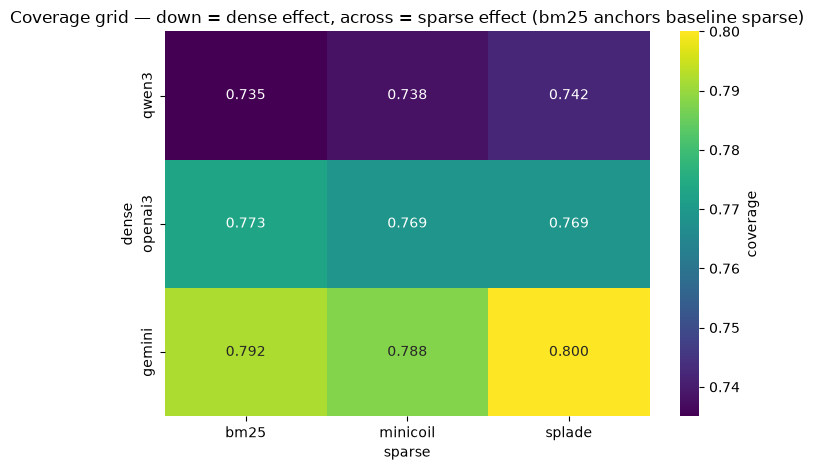

In [9]:
if len(table):
    cov = table.pivot(index="dense", columns="sparse", values="coverage")
    cov = cov.reindex(index=[d for d in DENSE if d in cov.index], columns=[s for s in SPARSE if s in cov.columns])
    fig, ax = plt.subplots(figsize=(1.6 * cov.shape[1] + 2, 1.1 * cov.shape[0] + 1.5))
    sns.heatmap(cov, annot=True, fmt=".3f", cmap="viridis", cbar_kws={"label": "coverage"}, ax=ax)
    ax.set_title("Coverage grid — down = dense effect, across = sparse effect (bm25 anchors baseline sparse)")
    plt.tight_layout(); plt.show()

## 4. Statistical significance — paired McNemar test

Every stack scores the **same 260 queries**, so a coverage gap needs a paired test, not a two-proportion comparison — McNemar's exact test on the *discordant* pairs (queries where the two stacks disagree; queries where both agree carry no information about which is better).

- **Sparse effect** — pairs within a fixed dense model (`bm25` vs `minicoil` vs `splade`).
- **Dense effect** — pairs across dense models with sparse fixed at `bm25`.

`p < 0.05` is the only kind of gap worth trusting; anything else is noise at this sample size, however large the raw coverage delta looks.

In [5]:
from itertools import combinations

from scipy.stats import binomtest

def _coverage_series(od):
    """Per-query coverage as a boolean Series indexed by query_id — the paired
    unit McNemar needs, one level below `metrics()`'s aggregate mean."""
    legN = pd.read_parquet(od / "labels.parquet")[["dataset", "query_id"] + SCORES]
    paired = leg1.merge(legN, on=["dataset", "query_id"], suffixes=("_1", "_2"))
    cand = paired[[f"{c}_2" for c in SCORES]].to_numpy(dtype=float)
    return pd.Series((cand.max(axis=1) > TOL), index=paired["query_id"].astype(str))

labelled = [(d, s) for d, s in STACKS if (out_dir(d, s) / "labels.parquet").exists()]
per_query = pd.DataFrame({f"{d}_{s}": _coverage_series(out_dir(d, s)) for d, s in labelled})

def mcnemar(a, b):
    """Paired significance between two stacks' per-query coverage in `per_query`.
    NOT a two-proportion test — every stack here scores the same queries, so only
    the discordant pairs (one stack hit, the other missed) carry information."""
    both = per_query[[a, b]].dropna()
    a_only = int((both[a] & ~both[b]).sum())
    b_only = int((~both[a] & both[b]).sum())
    n_disc = a_only + b_only
    p = 1.0 if n_disc == 0 else binomtest(min(a_only, b_only), n_disc, 0.5).pvalue
    return {"a": a, "b": b, "a_only": a_only, "b_only": b_only, "discordant": n_disc, "p": round(p, 4)}

def _stacks_for(dense=None, sparse=None):
    return [f"{d}_{s}" for d, s in labelled
            if (dense is None or d == dense) and (sparse is None or s == sparse)]

In [6]:
print("Sparse effect (dense fixed) — is the sparse leg significant?")
sparse_effect = pd.DataFrame(
    [mcnemar(a, b) for d in DENSE for a, b in combinations(_stacks_for(dense=d), 2)]
)
sparse_effect

Sparse effect (dense fixed) — is the sparse leg significant?


,a,b,a_only,b_only,discordant,p
0,qwen3_bm25,qwen3_minicoil,0,1,1,1.000
1,qwen3_bm25,qwen3_splade,0,2,2,0.500
2,qwen3_minicoil,qwen3_splade,0,1,1,1.000
3,openai3_bm25,openai3_minicoil,2,1,3,1.000
4,openai3_bm25,openai3_splade,2,1,3,1.000
5,openai3_minicoil,openai3_splade,2,2,4,1.000
6,gemini_bm25,gemini_minicoil,1,0,1,1.000
7,gemini_bm25,gemini_splade,0,2,2,0.500
8,gemini_bm25,gemini_os_distill,1,4,5,0.375
9,gemini_minicoil,gemini_splade,0,3,3,0.250


In [7]:
print("Dense effect (sparse=bm25 fixed) — is the dense leg significant?")
dense_effect = pd.DataFrame(
    [mcnemar(a, b) for a, b in combinations(_stacks_for(sparse="bm25"), 2)]
)
dense_effect

Dense effect (sparse=bm25 fixed) — is the dense leg significant?


,a,b,a_only,b_only,discordant,p
0,qwen3_bm25,openai3_bm25,7,17,24,0.0639
1,qwen3_bm25,gemini_bm25,2,17,19,0.0007
2,openai3_bm25,gemini_bm25,6,11,17,0.3323


# 5 — Sparse-only decomposition: the dense mask, removed

Full-stack coverage hides the sparse effect: the dense leg (~0.77–0.80 alone)
already covers most of what a stronger sparse leg adds, so 72 sparse-level
flips (os_distill vs bm25) collapse to net +4 in the grid above and every
full-stack McNemar reads as noise. Judged on its own column
(`score_sparse_only > 0`), the sparse ladder separates decisively —
bm25 0.392 → minicoil 0.412 → splade 0.515 → **os_distill 0.650**, every
os_distill pairwise p < 0.0001. Sparse-only coverage is dense-invariant, so
the gemini row speaks for all dense models.

In [ ]:
from itertools import combinations

from scipy.stats import binomtest

sparse_hits = {}
for d, s in STACKS:
    od = out_dir(d, s)
    if d == "gemini" and (od / "labels.parquet").exists():
        legN = pd.read_parquet(od / "labels.parquet")
        legN = legN.set_index(["dataset", "query_id"]).sort_index()
        sparse_hits[s] = legN["score_sparse_only"] > 0

print("sparse-only coverage (judged doc retrieved by the sparse leg alone):")
for name, hit in sparse_hits.items():
    print(f"  {name:10s} {hit.mean():.3f}  ({hit.sum()}/{len(hit)})")

rows = []
for a, b in combinations(sparse_hits, 2):
    x, y = sparse_hits[a].align(sparse_hits[b], join="inner")
    b_only, a_only = int((~x & y).sum()), int((x & ~y).sum())
    n_disc = a_only + b_only
    rows.append({"a": a, "b": b, "a_only": a_only, "b_only": b_only,
                 "discordant": n_disc,
                 "p": round(binomtest(min(a_only, b_only), n_disc).pvalue if n_disc else 1.0, 4)})
pd.DataFrame(rows)

## Reading it

- **The coverage grid is the answer — but check section 4 before trusting a gap.** Higher = the stack retrieved the judged doc for more queries (qrels-grounded, confound-robust). Rank stacks by coverage, then confirm the gap that matters clears `p < 0.05` in `sparse_effect`/`dense_effect` — a raw delta of a few queries out of 260 is routinely noise.
- **Read across a row** (`bm25 → splade → opensearch`, dense fixed) = the **sparse** contribution. The `bm25` column is the baseline's own sparse, so `splade`/`opensearch` minus `bm25` is the honest lift from a stronger sparse leg — the number the colleague's *+6.9-vs-BM25* did not give us: **opensearch vs SPLADE**, on our lane.
- **Read down a column** (dense fixed) = the **dense** contribution.
- **`gate_vs_bge` stays a switch-cost check, not the ranker** — a stack can top coverage yet FAIL the gate (replacing bge-small wholesale still loses some labels); judge by coverage.

**Caveats (unchanged and honest):** certifiable-decisive is encoder-biased; the gate's thresholds are hand-set placeholders; and `opensearch` is a `-doc-` (asymmetric) neural-sparse model run via `SparseEncoder` — its coverage here is its real number on this lane, but generalization to other lanes (esp. non-English) is a separate check.

- **Section 5 is where the sparse verdict lives.** Full-stack deltas are dense-masked; sparse-only coverage ranks the legs decisively, and os_distill (doc-only, inference-free query, 67M) wins by more over splade than splade wins over bm25.